## Exploratory Data Analysis

### Dataset Description
|                | Steel Plate Dataset |
|----------------|---------------------|
| Instances      | 1941                |
| Unique Classes | 7                   |
| Attributes     | 27                  |

The dataset does not contain any missing classes. Most of the data is continous, with only the steel type values (`TypeOfSteel_A300` and `TypeOfSteel_A400`) being binary classes. 

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mysklearn.mypytable import MyPyTable
from mysklearn.myutils import *

In [7]:
CLASSES = ["Pastry","Z_Scratch","K_Scratch","Stains","Dirtiness","Bumps","Other_Faults"]

data = MyPyTable().load_from_file("input_data/plate-data-clean.csv")

#### Distribution of Fault Type and X Minimum

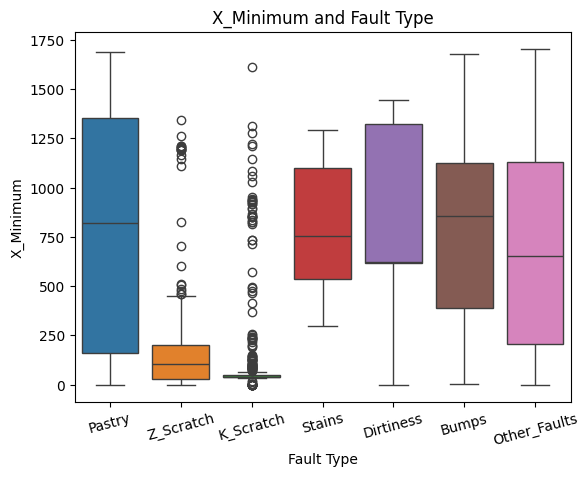

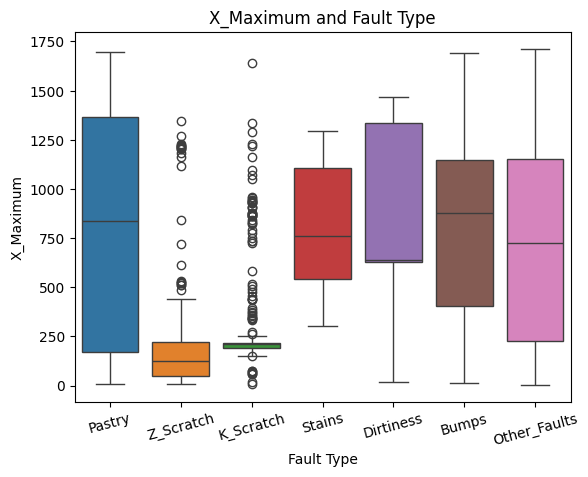

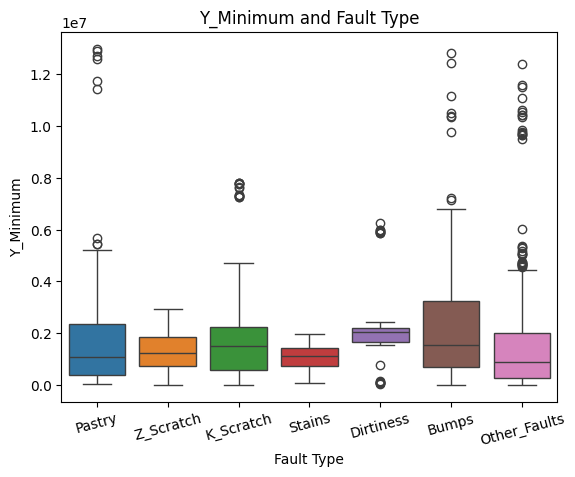

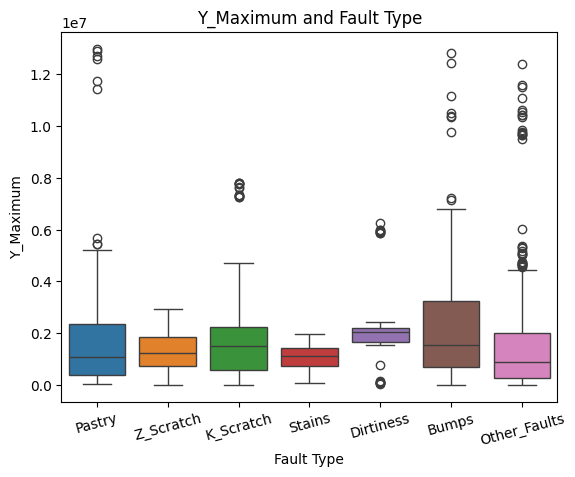

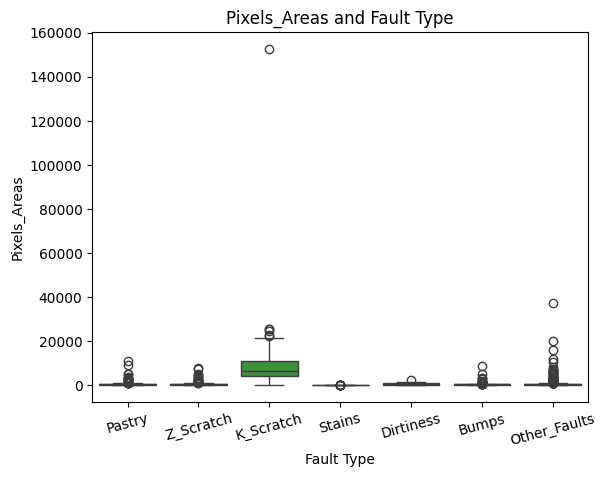

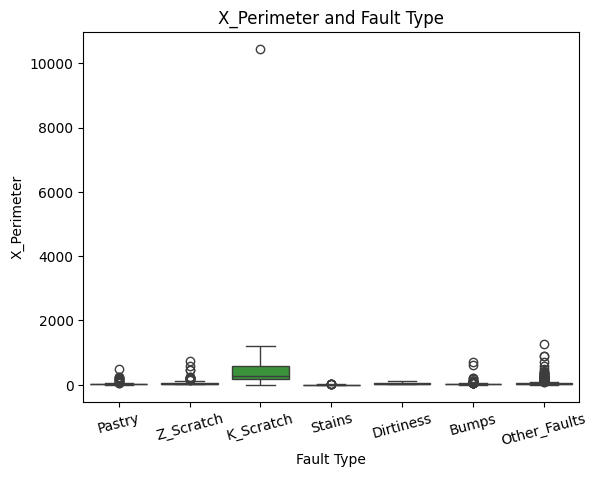

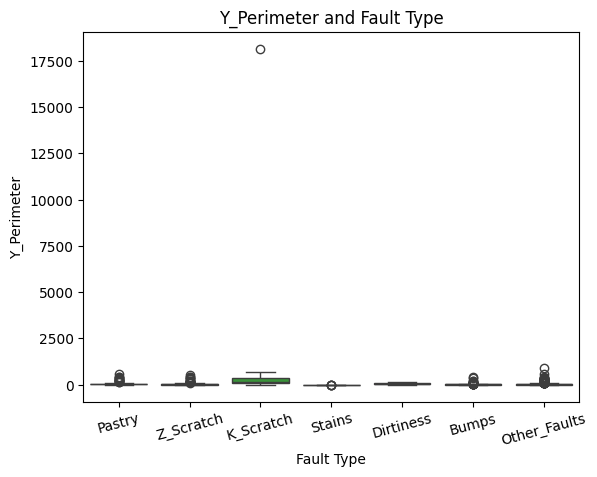

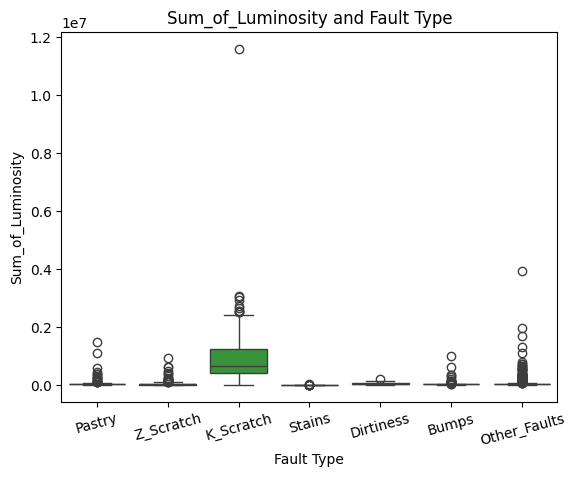

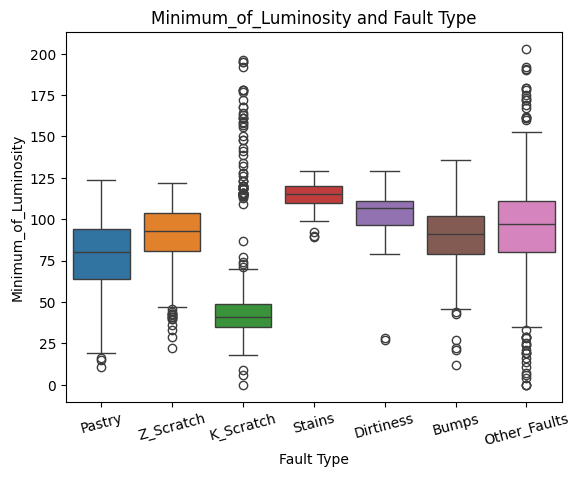

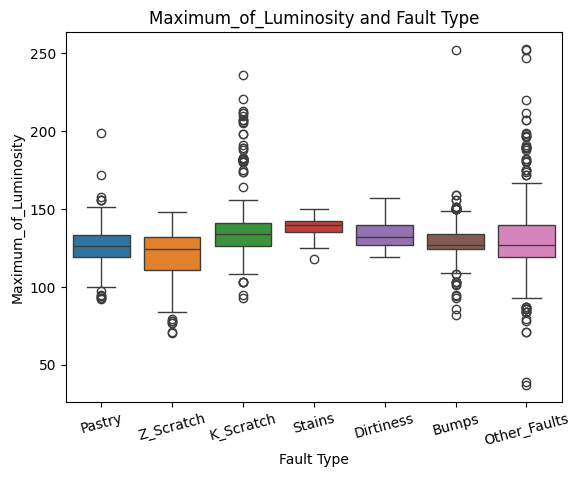

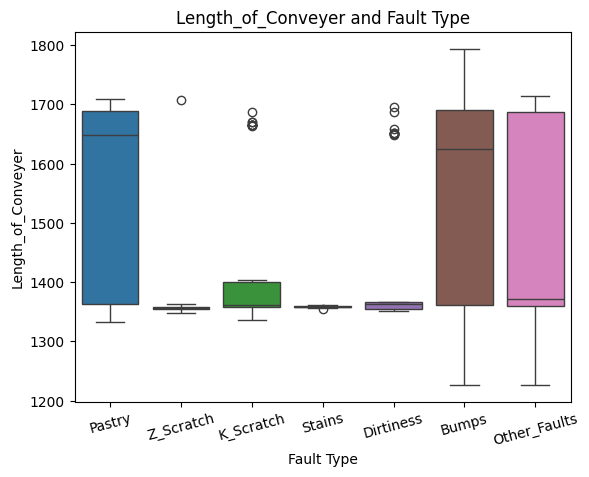

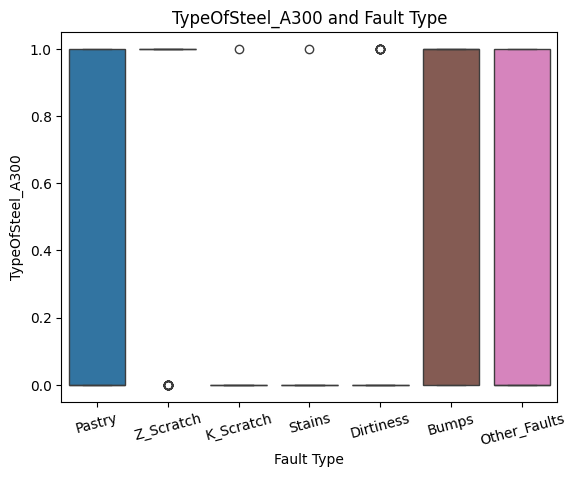

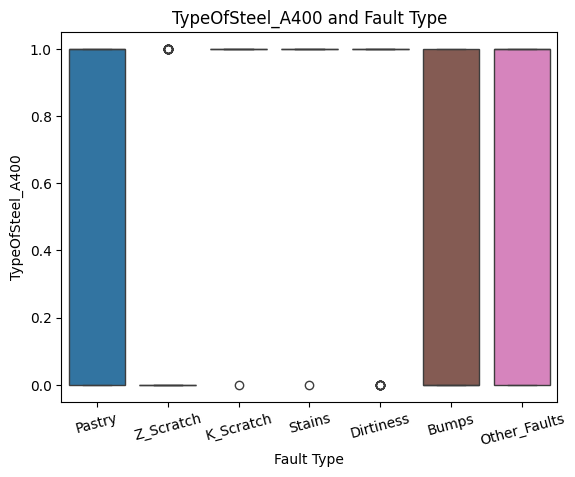

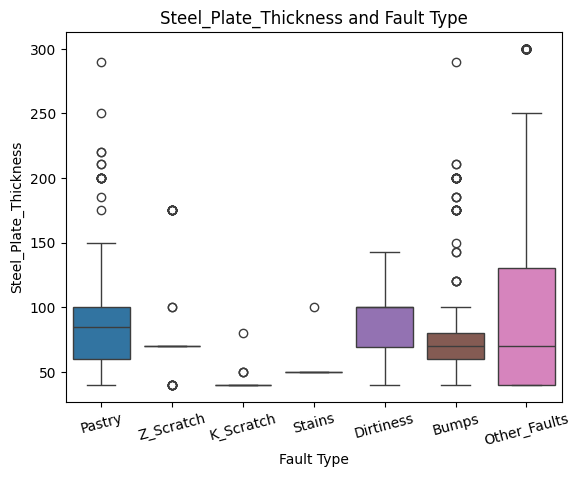

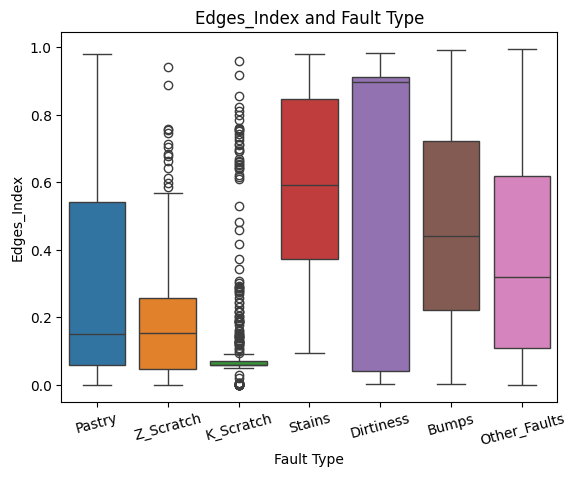

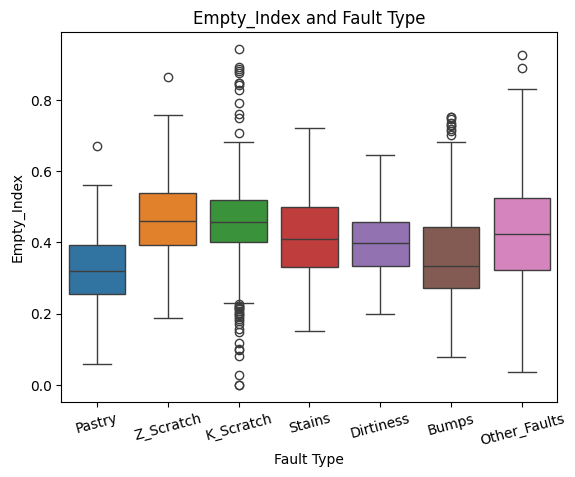

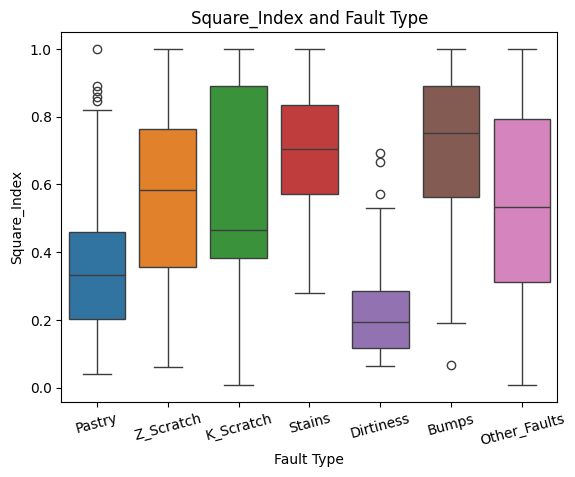

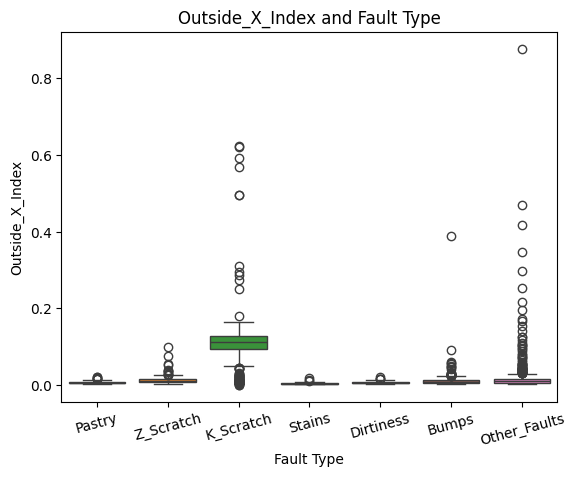

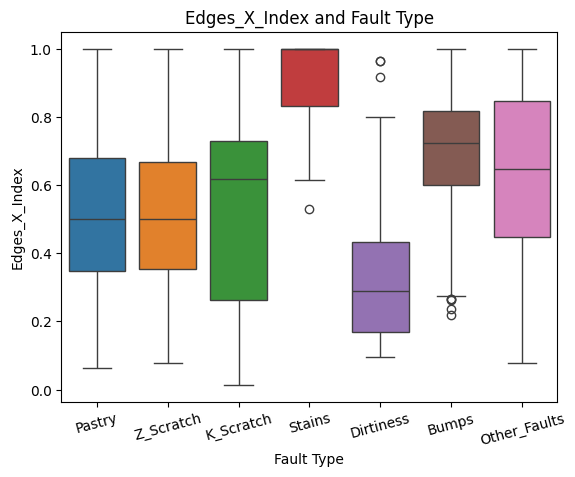

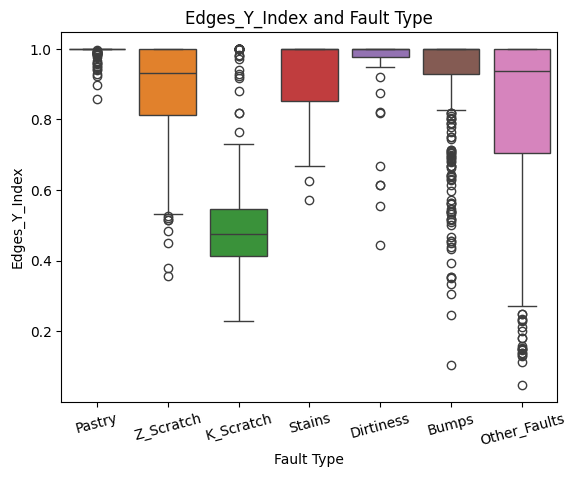

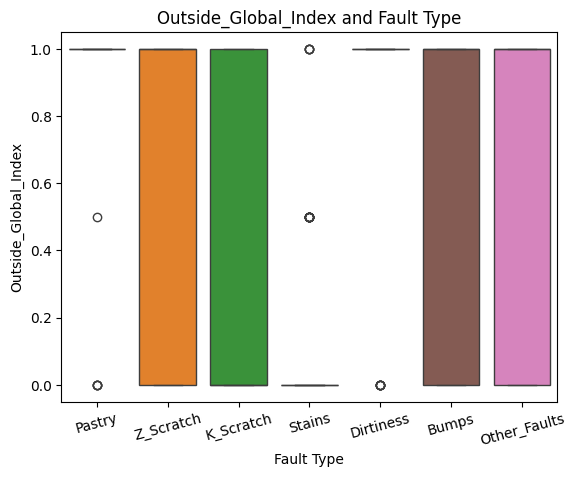

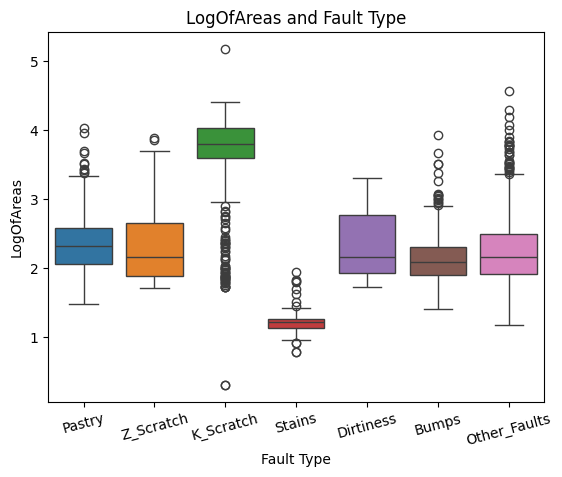

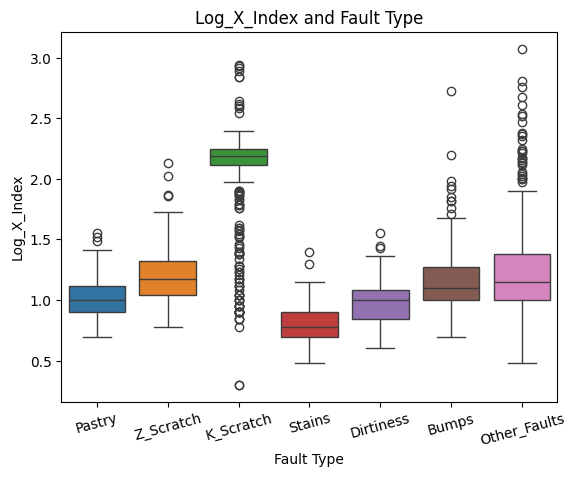

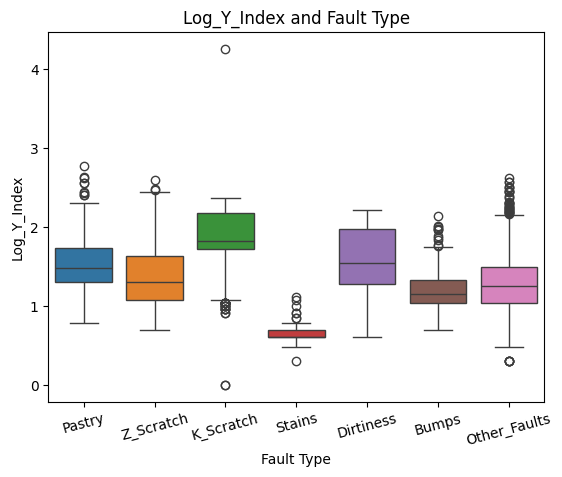

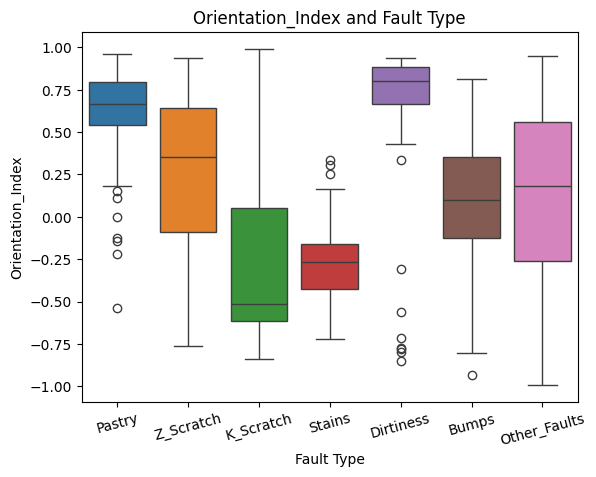

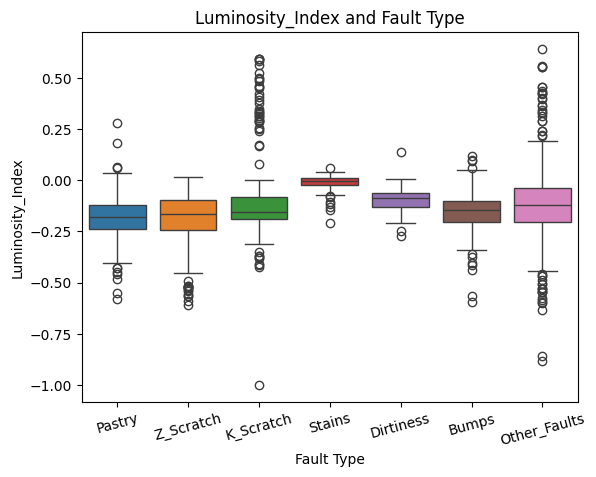

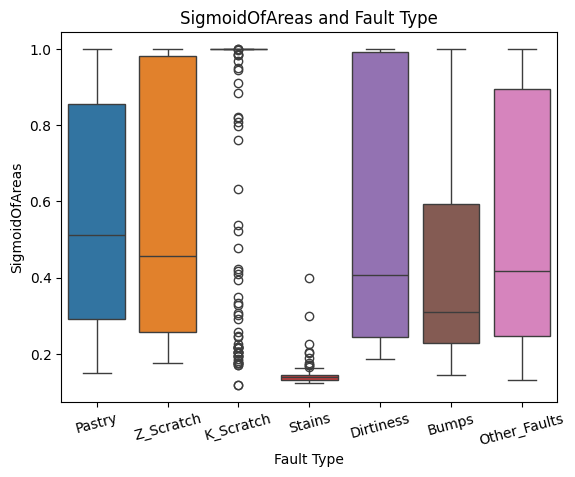

In [12]:
saved_atts = ["X_Minimum", "Pixels_Areas", "Steel_Plate_Thickness", "LogOfAreas"]

for attribute in data.column_names:
    if attribute == "Class":
        continue

    fig = plt.figure()
    sns.boxplot(data=eda_group_data_by_class(data, attribute))
    plt.xticks(rotation=15)
    plt.title(f"{attribute} and Fault Type")
    plt.xlabel("Fault Type")
    plt.ylabel(f"{attribute}")
    plt.show()

    if attribute in saved_atts:
        fig.savefig(f"media/boxplot_{attribute}.png")

#### Count Distributions for All Attributes

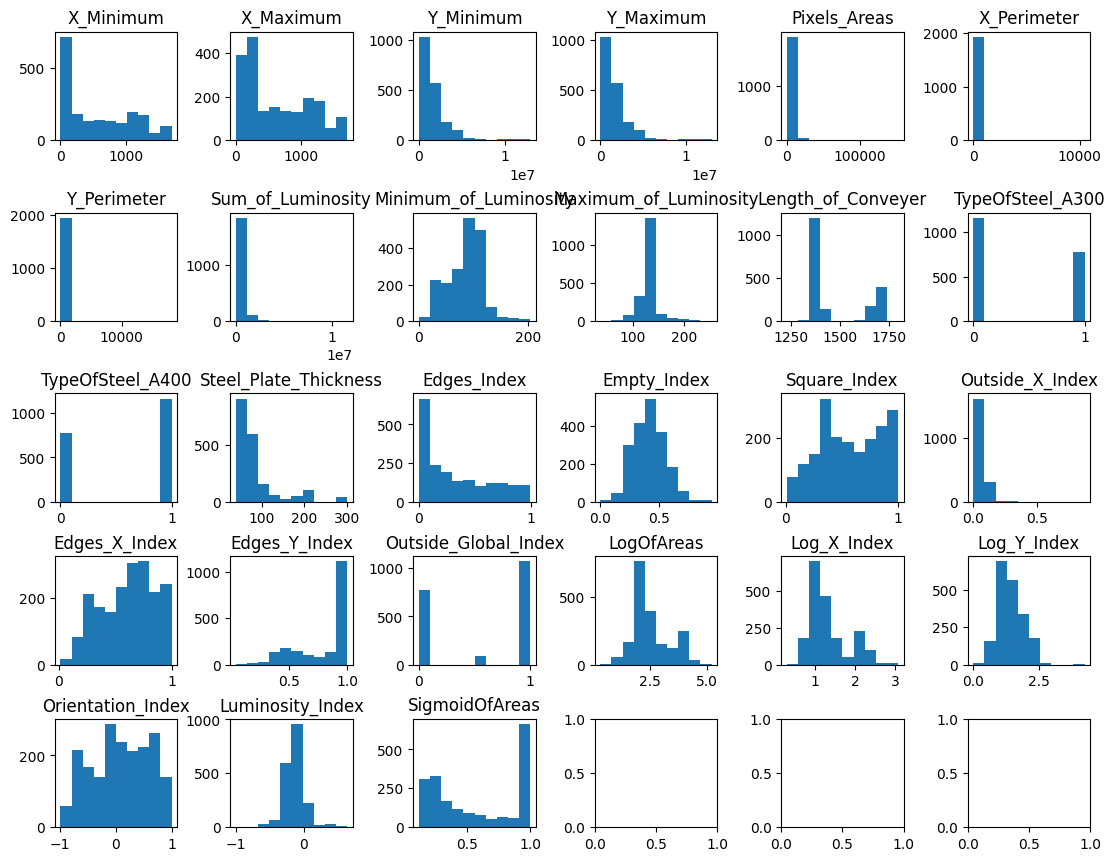

In [9]:
import copy
col_count = 6

tmp_classes = copy.deepcopy(data.column_names)
tmp_classes.remove('Class')
tmp_fig, ax = plt.subplots((len(tmp_classes)//col_count)+1, col_count, layout='constrained', figsize=(8,8))
tmp_fig.set_size_inches(11, 8.5)
for col in range(len(tmp_classes)):
    tmp = ax.flat[col]
    tmp.hist(data.get_column(data.column_names[col]))
    tmp.set_title(data.column_names[col])
plt.savefig('media/dist.png')

#### Occurrences for Each Class

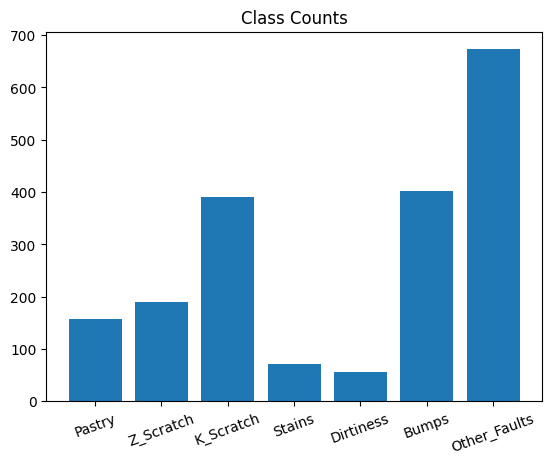

In [10]:
counts = {k: 0 for k in CLASSES}
for result in data.get_column('Class'):
    counts[result]+=1

fig, ax = plt.subplots()
ax.set_title("Class Counts")
ax.bar(counts.keys(), counts.values())
ax.tick_params('x', rotation=20)
fig.savefig('media/counts.png')